In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [73]:
df = pd.read_csv(r"C:\Users\bda\Desktop\261100660031\AML_LAB\Lab_5\Salary_Data.csv")

In [74]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [75]:
df.duplicated().sum()

np.int64(0)

In [76]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [77]:
x = df[["YearsExperience"]]
x

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [78]:
y = df["Salary"]
y

0      39343.0
1      46205.0
2      37731.0
3      43525.0
4      39891.0
5      56642.0
6      60150.0
7      54445.0
8      64445.0
9      57189.0
10     63218.0
11     55794.0
12     56957.0
13     57081.0
14     61111.0
15     67938.0
16     66029.0
17     83088.0
18     81363.0
19     93940.0
20     91738.0
21     98273.0
22    101302.0
23    113812.0
24    109431.0
25    105582.0
26    116969.0
27    112635.0
28    122391.0
29    121872.0
Name: Salary, dtype: float64

In [79]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 1/3, random_state = 42)

In [80]:
model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [81]:
print("Intercept : ", model.intercept_)
print("Slope : ", model.coef_[0])

Intercept :  25324.33537924433
Slope :  9426.038769074834


In [82]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

print("MAE       : ", mean_absolute_error(y_test, y_pred))
print("MSE       : ", mean_squared_error(y_test, y_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared : ", r2_score(y_test, y_pred))

MAE       :  4956.5232614449005
MSE       :  35301898.887134895
RMSE      :  5941.540110706558
R-squared :  0.9553063138044949


        #After ridge
        MAE       :  4973.600767464554
        MSE       :  35424098.508684516
        RMSE      :  5951.81472398835
        R-squared :  0.9551516039528745


C:\Users\bda\AppData\Local\Temp\ipykernel_16888\1698129918.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


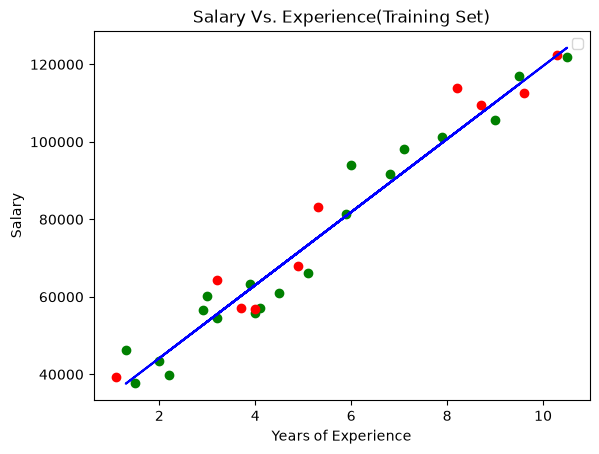

In [83]:
plt.scatter(x_train, y_train, color = 'green')
plt.scatter(x_test, y_test, color = 'red')
plt.plot(x_train, model.predict(x_train), color = 'blue')

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Vs. Experience(Training Set)")
#plt.grid(True)
plt.legend()
plt.show()


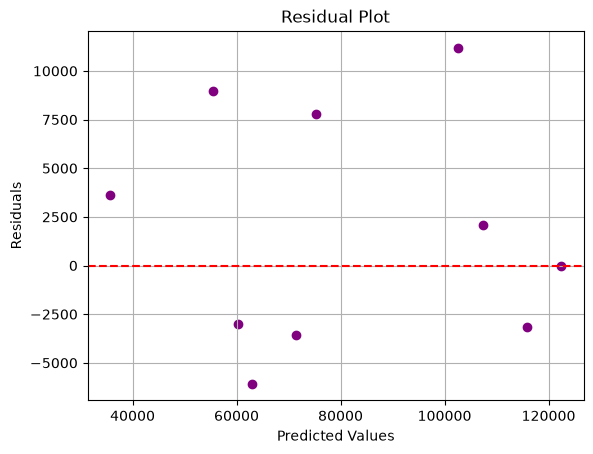

In [84]:
y_pred_test = model.predict(x_test)

residuals = y_test - y_pred_test

plt.scatter(y_pred_test, residuals, color = "purple")
plt.axhline(y = 0, color = "red", linestyle = "--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [85]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

In [86]:
#Instead of lambda is alpha

model = make_pipeline(
    StandardScaler(),
    Ridge(alpha = 1.0)
    )

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [87]:
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

model = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas = [0.01, 0.1, 1, 10, 100])
)

model.fit(x_train, y_train)

ridge_model = model.named_steps["ridgecv"]
print("Best alpha : ", ridge_model.alpha_)

Best alpha :  0.1


In [92]:
#Instead of lambda is alpha

model = make_pipeline(
    StandardScaler(),
    Ridge(alpha = 0.1)
    )

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [93]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

print("MAE       : ", mean_absolute_error(y_test, y_pred))
print("MSE       : ", mean_squared_error(y_test, y_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared : ", r2_score(y_test, y_pred))

MAE       :  4973.600767464554
MSE       :  35424098.508684516
RMSE      :  5951.81472398835
R-squared :  0.9551516039528745


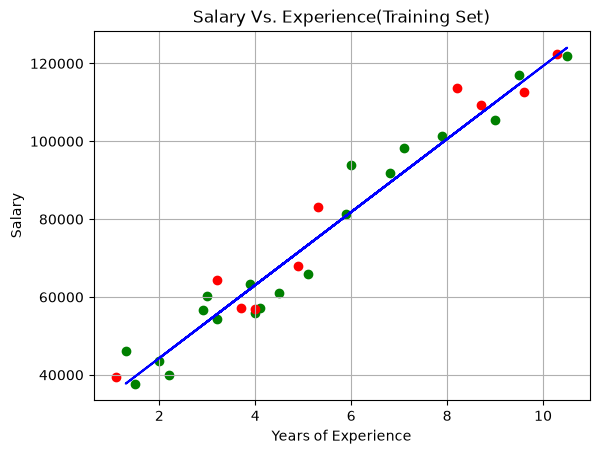

In [94]:
plt.scatter(x_train, y_train, color = 'green')
plt.scatter(x_test, y_test, color = 'red')
plt.plot(x_train, model.predict(x_train), color = 'blue')

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Vs. Experience(Training Set)")
plt.grid(True)
#plt.legend()
plt.show()
